<a href="https://colab.research.google.com/github/PrarthanaShende/AI-Projects-/blob/main/Text_Classification_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Text Classification project
#### Project Objective: Build a text classification model that predicts the intent of customer review whether the review is positive or negative.


## Data Gathering

In [1]:
import pandas as pd
path = r'https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/Restaurant_Reviews.tsv'
df = pd.read_csv(path, sep='\t')
df.head()

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


* Liked = 1 : Positive review
* Not Liked = 0 : Negative review

In [2]:
df['Review'].head(10)

,Review
0,Wow... Loved this place.
1,Crust is not good.
2,Not tasty and the texture was just nasty.
3,Stopped by during the late May bank holiday of...
4,The selection on the menu was great and so wer...
5,Now I am getting angry and I want my damn pho.
6,Honeslty it didn't taste THAT fresh.)
7,The potatoes were like rubber and you could te...
8,The fries were great too.
9,A great touch.


## Data preprocessing

In [3]:
df['Review'][0]

'Wow... Loved this place.'

In [4]:
s1= df['Review'][0]
s1.lower()

'wow... loved this place.'

In [5]:
import re
s1= s1.lower()
pattern = r'[^a-z ]'
s1= re.sub(pattern,'', s1)
s1

'wow loved this place'

In [6]:
def preprocess (text):
  text = text.lower()
  pattern = r'[^a-z ]'
  text = re.sub(pattern, '', text)
  return text

In [7]:
df['Review_preprocessed'] = df['Review'].apply(preprocess)
df.head()

,Review,Liked,Review_preprocessed
0,Wow... Loved this place.,1,wow loved this place
1,Crust is not good.,0,crust is not good
2,Not tasty and the texture was just nasty.,0,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,1,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,1,the selection on the menu was great and so wer...


In [8]:
df.head(10)

,Review,Liked,Review_preprocessed
0,Wow... Loved this place.,1,wow loved this place
1,Crust is not good.,0,crust is not good
2,Not tasty and the texture was just nasty.,0,not tasty and the texture was just nasty
3,Stopped by during the late May bank holiday of...,1,stopped by during the late may bank holiday of...
4,The selection on the menu was great and so wer...,1,the selection on the menu was great and so wer...
5,Now I am getting angry and I want my damn pho.,0,now i am getting angry and i want my damn pho
6,Honeslty it didn't taste THAT fresh.),0,honeslty it didnt taste that fresh
7,The potatoes were like rubber and you could te...,0,the potatoes were like rubber and you could te...
8,The fries were great too.,1,the fries were great too
9,A great touch.,1,a great touch


In [9]:
df['Review_preprocessed'].head()

,Review_preprocessed
0,wow loved this place
1,crust is not good
2,not tasty and the texture was just nasty
3,stopped by during the late may bank holiday of...
4,the selection on the menu was great and so wer...


## Separate X and Y features

X: Review_Preprocessed

Y : Liked

In [10]:
x = df['Review_preprocessed']
y = df['Liked']
x[:10]

,Review_preprocessed
0,wow loved this place
1,crust is not good
2,not tasty and the texture was just nasty
3,stopped by during the late may bank holiday of...
4,the selection on the menu was great and so wer...
5,now i am getting angry and i want my damn pho
6,honeslty it didnt taste that fresh
7,the potatoes were like rubber and you could te...
8,the fries were great too
9,a great touch


## Vectorization

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()
xpre = tfidf.fit_transform(x).toarray()

In [12]:
xpre[:6]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Split the data into training and testing

In [13]:
from sklearn.model_selection import train_test_split
xtrain,xtest, ytrain, ytest = train_test_split(xpre, y, train_size =0.85, random_state =21)

## Model Building
While building and tuning the model, you can tweak below parameters and see if there is significant change in the model predictions. Awalys restart kernel and run all cells

1. while splitting the data into training and testing, you can modify the size
2. you can increase more neurons to the hidden layers
3. you can add more layers to the architechture
4. you can update the patience levels in ReduceLR
5. you can update the batch size


In [14]:
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from keras.callbacks import ReduceLROnPlateau

# Intialize the model
model = Sequential()

# Add the layers
model.add(Input(shape=(xtrain.shape[1],)))

# Add the hidden layer
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(rate=0.3))

# Add the hidden layer
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(rate=0.2))

# Add the hidden layer
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(rate=0.1))

# Add the Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
learning_rate_reduction = ReduceLROnPlateau(moniter='val_loss', patience=2, min_lr=0.0001,factor=0.85, verbose=1)

In [15]:
nn= model.fit(xtrain,ytrain, validation_split=0.2, epochs=15, callbacks=[learning_rate_reduction],batch_size=8)

Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.5103 - loss: 0.6923 - val_accuracy: 0.6294 - val_loss: 0.6851 - learning_rate: 0.0010
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7471 - loss: 0.6263 - val_accuracy: 0.7941 - val_loss: 0.5515 - learning_rate: 0.0010
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9074 - loss: 0.3100 - val_accuracy: 0.8059 - val_loss: 0.4327 - learning_rate: 0.0010
Epoch 4/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9721 - loss: 0.1035 - val_accuracy: 0.8176 - val_loss: 0.4923 - learning_rate: 0.0010
Epoch 5/15
68/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9967 - loss: 0.0367
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0008500000403728336.
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9941 - loss: 0.0360 - val_accuracy: 0.7353 - val_loss: 0.6481 - learning_rate: 0.0010
Epoch 6/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9971 - loss: 0.0168 - val_accuracy: 

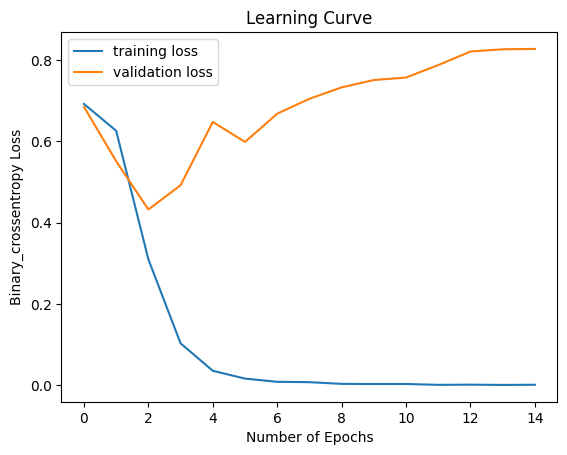

In [17]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label= 'training loss')
plt.plot(nn.history['val_loss'],label= 'validation loss')
plt.title('Learning Curve')
plt.xlabel("Number of Epochs")
plt.ylabel("Binary_crossentropy Loss")
plt.legend()
plt.show()

In [18]:
model.evaluate(xtrain,ytrain)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9612 - loss: 0.1657


[0.165690079331398, 0.9611764550209045]

In [19]:
model.evaluate(xtest,ytest)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.8333 - loss: 0.5640


[0.5639724731445312, 0.8333333134651184]

Accuracy score is 80% . We can consider this model as final model

In [20]:
import joblib
joblib.dump(model,"Text_Classificaiton_Model.joblib")

['Text_Classificaiton_Model.joblib']

In [21]:
model.save('Text_Classificaiton.keras')

## Out of sample predictions

In [22]:
review='Food is not good will not come again...'


In [23]:
review_updated= preprocess(review)
review_updated

'food is not good will not come again'

In [24]:
review_updated_pre= tfidf.transform([review_updated]).toarray()
review_updated_pre

array([[0., 0., 0., ..., 0., 0., 0.]])

In [25]:
probs= model.predict(review_updated_pre)
probs

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 983ms/step


array([[0.00300138]], dtype=float32)

In [26]:
if probs>0.5:
  print('postive review')
else:
  print('negative review')

negative review
